# Task 1 - Financial AI: LLM-Powered Equity Research Assistant

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GimsaraK/CDAZZDEV-MLE-Gimsara_Elgiriyage/blob/main/task1_financial/task1_equity_research.ipynb)

CDAZZDEV Senior Machine Learning Engineer Technical Assessment - Gimsara Elgiriyage

**Part 1A** builds the data ingestion and feature engineering module. All logic lives in reusable, unit-tested modules under [`task1_financial/src/`](src/); this notebook orchestrates them and shows the evidence.

| Module | Responsibility |
|---|---|
| `config.py` | Every tunable constant (no magic numbers elsewhere) |
| `data.py` | yfinance OHLCV + company info, validation and cleaning, snapshot fallback |
| `indicators.py` | SMA, EMA, Wilder RMA, RSI, MACD, Bollinger Bands from first principles |
| `news.py` | yfinance news + Google News RSS, de-duplication, snapshot fallback |
| `summary.py` | Momentum composite signal and the validated summary dictionary |
| `pipeline.py` | End-to-end orchestration that never raises |

## 0. Setup

In Colab the public repository is cloned and its requirements installed. Locally, the repository root is added to `sys.path`. Part 1A needs **no API keys** (yfinance and Google News RSS are keyless); Part 1B will read keys from Colab Secrets / `.env`, never from code.

In [1]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Environment setup: works both in Google Colab and in a local clone of the repository.
# In Colab we clone the public repo and install requirements; locally we just locate the repo root.
import subprocess
import sys
from pathlib import Path

# Public repository that holds the pipeline source code (src/) and the data snapshot.
REPO_URL = "https://github.com/GimsaraK/CDAZZDEV-MLE-Gimsara_Elgiriyage.git"
REPO_NAME = "CDAZZDEV-MLE-Gimsara_Elgiriyage"
# Colab pre-imports the google.colab module, so its presence tells us where we are running.
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Clone only once per Colab session; --depth 1 skips the git history to save time.
    repo_root = Path("/content") / REPO_NAME
    if not repo_root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo_root)], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(repo_root / "task1_financial" / "requirements.txt")],
        check=True,
    )
else:
    # Local run: this notebook lives in task1_financial/, so the repository root is its parent.
    cwd = Path.cwd().resolve()
    repo_root = cwd.parent if cwd.name == "task1_financial" else cwd

# Put the repo root on the import path so `from task1_financial.src import ...` works.
# Importing through the task folder avoids clashing with the other tasks' `src` packages.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
# Only the folder name is printed so no absolute local paths leak into the outputs.
print(f"Running in Colab: {IN_COLAB}")
print(f"Repository root : .../{repo_root.name}")

Running in Colab: False
Repository root : .../CDAZZDEV-SMLE


In [2]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Standard library and third-party imports used throughout the notebook.
import json
from unittest import mock

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Pipeline modules. All business logic lives in src/; the notebook only orchestrates and displays.
from task1_financial.src import config
from task1_financial.src import data as data_module
from task1_financial.src import indicators as ind
from task1_financial.src import news as news_module
from task1_financial.src.data import MarketData, load_market_data, validate_and_clean_ohlcv
from task1_financial.src.logging_utils import configure_logging
from task1_financial.src.news import get_headlines, news_to_records
from task1_financial.src.pipeline import run_pipeline
from task1_financial.src.llm import load_api_keys, recommend_signal, score_headlines
from task1_financial.src.summary import build_summary

# Render charts inside the notebook output.
%matplotlib inline
# Pipeline-wide logging (retries, fallbacks and data-quality warnings are logged with timestamps).
logger = configure_logging()
# Wider pandas display so the tables below are not truncated.
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 110)

## 1. Configuration

All parameters come from `src/config.py`. The history window is a **relative period string** (`"3y"`), never a hardcoded date: 3 years satisfies the 2-year minimum and leaves a full 2 years of valid 200-day SMA values after warm-up.

In [3]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Show the key settings from src/config.py so a reviewer can see every parameter used in one place.
# Nothing is hardcoded in the notebook: changing config.py changes the whole run.
settings = {
    "Ticker": config.TICKER,
    "History period (relative)": config.HISTORY_PERIOD,
    "Interval": config.HISTORY_INTERVAL,
    "Minimum history (years)": config.MIN_HISTORY_YEARS,
    "SMA windows": f"{config.SMA_SHORT_WINDOW}, {config.SMA_LONG_WINDOW}",
    "RSI period / smoothing": f"{config.RSI_PERIOD} / Wilder RMA (alpha = 1/{config.RSI_PERIOD})",
    "MACD (fast, slow, signal)": f"({config.MACD_FAST}, {config.MACD_SLOW}, {config.MACD_SIGNAL})",
    "Bollinger (window, std, ddof)": f"({config.BB_WINDOW}, {config.BB_NUM_STD}, {config.BB_STD_DDOF} = population)",
    "News target / minimum": f"{config.NEWS_TARGET_COUNT} / {config.NEWS_MIN_COUNT}",
    "Retry attempts": config.RETRY_MAX_ATTEMPTS,
}
# Display as a two-column table (Setting / Value).
display(pd.DataFrame(settings.items(), columns=["Setting", "Value"]).set_index("Setting"))

,Value
Setting,
Ticker,AAPL
History period (relative),3y
Interval,1d
Minimum history (years),2
SMA windows,"50, 200"
RSI period / smoothing,14 / Wilder RMA (alpha = 1/14)
"MACD (fast, slow, signal)","(12, 26, 9)"
"Bollinger (window, std, ddof)","(20, 2, 0 = population)"
News target / minimum,15 / 10


# Part 1A - Financial Data Pipeline

## 2. OHLCV Data Fetch

`load_market_data` fetches daily OHLCV with `auto_adjust=False`, so both the raw `Close` (matches quoted prices) and the split/dividend-adjusted `Adj Close` (used for indicators and returns) are available. Network calls are retried with exponential backoff; if the live fetch fails, the last committed snapshot in `task1_financial/data/` is used and the fallback is logged.

In [4]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Step 1A.1 - Fetch 3 years of daily OHLCV data and company info for the ticker.
# load_market_data retries network errors, cleans/validates the data, saves a snapshot,
# and falls back to the committed snapshot in task1_financial/data/ if the live fetch fails.
market = load_market_data(config.TICKER)
ohlcv = market.ohlcv
quality = market.quality

# The specification requires at least 2 years of history; stop early if we did not get it.
assert quality.meets_min_history, f"Only {quality.span_years} years of history"
# Report where the data came from (live or snapshot), its size, range and any quality issues.
print(f"Ticker      : {market.ticker} ({market.info.get('longName', 'n/a')})")
print(f"Source      : {quality.source} (fetched at {quality.fetched_at})")
print(f"Rows        : {quality.rows} daily bars")
print(f"Date range  : {quality.start_date} -> {quality.end_date}  ({quality.span_years} years >= {config.MIN_HISTORY_YEARS} required)")
print(f"Data quality: {quality.warnings or 'no issues found'}")
# Show the first and last rows as a quick sanity check of the cleaned data.
display(ohlcv[list(config.REQUIRED_OHLCV_COLUMNS)].head(3))
display(ohlcv[list(config.REQUIRED_OHLCV_COLUMNS)].tail(3))

20:34:05 | INFO    | task1.data | Fetching 3y OHLCV history for AAPL (interval=1d)


20:34:06 | INFO    | task1.data | Saved market data snapshot for AAPL to task1_financial/data


20:34:06 | INFO    | task1.data | Loaded 753 live rows for AAPL (2023-10-09 to 2026-10-08)


Ticker      : AAPL (Apple Inc.)
Source      : live (fetched at 2026-10-08T15:04:06+00:00)
Rows        : 753 daily bars
Date range  : 2023-10-09 -> 2026-10-08  (3.0 years >= 2 required)
Data quality: no issues found


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-10-09,176.809998,179.050003,175.800003,178.990005,176.601456,42390800
2023-10-10,178.100006,179.720001,177.949997,178.389999,176.009476,43698000
2023-10-11,178.199997,179.850006,177.600006,179.800003,177.400635,47551100


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2026-10-06,332.279999,334.380005,330.619995,333.630005,333.630005,30449000
2026-10-07,336.959991,338.670013,332.779999,336.670013,336.670013,34128200
2026-10-08,336.829987,338.339996,335.899994,337.538696,337.538696,5983683


## 3. Technical Indicators (from first principles, no TA-Lib)

Computed on **Adj Close** by `src/indicators.py`:

| Indicator | Definition |
|---|---|
| SMA(n) | $SMA_t = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}$, for n = 50 and 200 |
| EMA(n) | $EMA_t = \alpha P_t + (1-\alpha) EMA_{t-1}$, $\alpha = 2/(n+1)$, seeded with the first price (explicit recursion) |
| RSI(14) | $gain_t=\max(\Delta P_t,0)$, $loss_t=\max(-\Delta P_t,0)$; Wilder RMA: seed = mean of the first 14, then $RMA_t = (RMA_{t-1}\cdot 13 + x_t)/14$; $RSI = 100 - \frac{100}{1 + RMA(gain)/RMA(loss)}$ |
| MACD(12, 26, 9) | $MACD = EMA_{12} - EMA_{26}$; $Signal = EMA_9(MACD)$; $Histogram = MACD - Signal$ |
| Bollinger(20, 2) | $Middle = SMA_{20}$; $Upper/Lower = Middle \pm 2\sigma_{20}$ (population std); $\%B = \frac{P - Lower}{Upper - Lower}$ |

Every indicator is NaN until its warm-up window is complete, so no misleading early values are produced.

In [5]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Step 1A.2 - Compute SMA-50/200, RSI-14, MACD(12,26,9) and Bollinger Bands(20,2).
# add_indicators returns a copy of the price table with one new column per indicator,
# all computed on Adj Close so dividends and splits do not create false signals.
prices = ind.add_indicators(ohlcv)

# Latest row = most recent trading session.
latest = prices.iloc[-1]
# Table of the latest Adj Close plus every indicator value, rounded for display.
latest_table = pd.DataFrame(
    {
        "Value": [latest[config.PRICE_COL_ADJ], *[latest[c] for c in ind.INDICATOR_COLUMNS]],
    },
    index=[config.PRICE_COL_ADJ, *ind.INDICATOR_COLUMNS],
).round(4)
print(f"Latest indicator values as of {prices.index[-1].date()}:")
display(latest_table)
# Each indicator needs a warm-up window (e.g. SMA-200 needs 200 sessions) before its first value;
# this shows the first date each one becomes available.
print("First valid date per indicator (warm-up):")
display(pd.Series({c: prices[c].first_valid_index().date() for c in ind.INDICATOR_COLUMNS}, name="first_valid"))

Latest indicator values as of 2026-10-08:


,Value
Adj Close,337.5387
SMA_50,322.2290
SMA_200,290.0559
RSI_14,58.5715
MACD,3.3309
MACD_Signal,3.9488
MACD_Hist,-0.6179
BB_Middle,335.0264
BB_Upper,341.3936
BB_Lower,328.6593


First valid date per indicator (warm-up):


SMA_50          2023-12-18
SMA_200         2024-07-25
RSI_14          2023-10-27
MACD            2023-11-13
MACD_Signal     2023-11-24
MACD_Hist       2023-11-24
BB_Middle       2023-11-03
BB_Upper        2023-11-03
BB_Lower        2023-11-03
BB_PctB         2023-11-03
BB_Bandwidth    2023-11-03
Name: first_valid, dtype: object

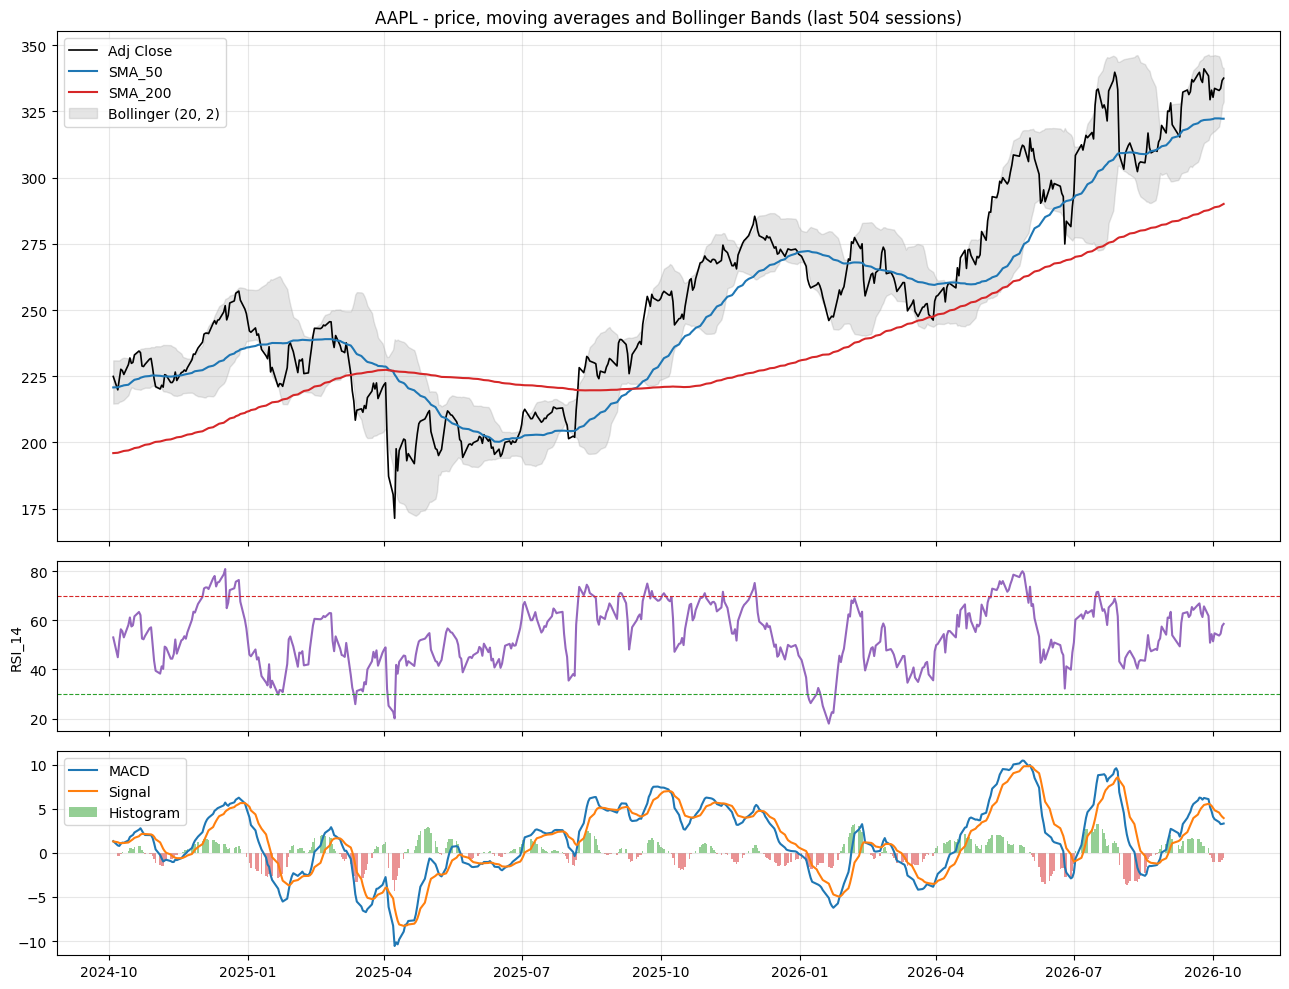

Chart saved to task1_financial\outputs\AAPL_technical_chart.png


In [6]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Visual check of the indicators over the most recent sessions (window size set in config).
# Three stacked panels sharing the same date axis: price, RSI and MACD.
recent = prices.tail(config.CHART_LOOKBACK_SESSIONS)
fig, (ax_price, ax_rsi, ax_macd) = plt.subplots(
    3, 1, figsize=(13, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1.2]}
)

# Panel 1: Adj Close with the two moving averages and the Bollinger Band envelope (shaded).
ax_price.plot(recent.index, recent[config.PRICE_COL_ADJ], label="Adj Close", color="black", linewidth=1.2)
ax_price.plot(recent.index, recent[ind.COL_SMA_SHORT], label=ind.COL_SMA_SHORT, color="tab:blue")
ax_price.plot(recent.index, recent[ind.COL_SMA_LONG], label=ind.COL_SMA_LONG, color="tab:red")
ax_price.fill_between(recent.index, recent[ind.COL_BB_LOWER], recent[ind.COL_BB_UPPER], color="tab:gray", alpha=0.2,
                      label=f"Bollinger ({config.BB_WINDOW}, {config.BB_NUM_STD})")
ax_price.set_title(f"{market.ticker} - price, moving averages and Bollinger Bands (last {len(recent)} sessions)")
ax_price.legend(loc="upper left")
ax_price.grid(alpha=0.3)

# Panel 2: RSI with the overbought (70) and oversold (30) reference lines.
ax_rsi.plot(recent.index, recent[ind.COL_RSI], color="tab:purple")
ax_rsi.axhline(config.RSI_OVERBOUGHT, color="tab:red", linestyle="--", linewidth=0.8)
ax_rsi.axhline(config.RSI_OVERSOLD, color="tab:green", linestyle="--", linewidth=0.8)
ax_rsi.set_ylabel(ind.COL_RSI)
ax_rsi.grid(alpha=0.3)

# Panel 3: MACD line, signal line and histogram (green when MACD > signal, red otherwise).
ax_macd.plot(recent.index, recent[ind.COL_MACD], label="MACD", color="tab:blue")
ax_macd.plot(recent.index, recent[ind.COL_MACD_SIGNAL], label="Signal", color="tab:orange")
ax_macd.bar(recent.index, recent[ind.COL_MACD_HIST], label="Histogram",
            color=np.where(recent[ind.COL_MACD_HIST] >= 0, "tab:green", "tab:red"), width=1.0, alpha=0.5)
ax_macd.legend(loc="upper left")
ax_macd.grid(alpha=0.3)

# Save the chart to task1_financial/outputs/ so it can be reused in the research brief.
fig.tight_layout()
config.OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
chart_path = config.OUTPUTS_DIR / config.CHART_OUTPUT_TEMPLATE.format(ticker=market.ticker)
fig.savefig(chart_path, dpi=config.CHART_DPI)
plt.show()
print(f"Chart saved to {chart_path.relative_to(repo_root)}")

### 3.1 Verification against an independent implementation

The open-source [`ta`](https://github.com/bukosabino/ta) library is used **only here, for validation** - never inside the pipeline. The comparison covers the last two years (after every warm-up window). Small RSI differences would come only from seeding (`ta` seeds Wilder's average with the first change; we follow Wilder's original simple-average seed) and decay geometrically, so they vanish long before the comparison window.

In [7]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Verification: recompute every indicator with the independent `ta` library and compare.
# `ta` is used ONLY here as a test oracle; the pipeline itself uses our own implementations.
from ta.momentum import RSIIndicator
from ta.trend import MACD as TaMACD
from ta.trend import SMAIndicator
from ta.volatility import BollingerBands

# Use the same Adj Close series and the same parameters as our implementation.
close = prices[config.PRICE_COL_ADJ]
ta_macd = TaMACD(close, window_slow=config.MACD_SLOW, window_fast=config.MACD_FAST, window_sign=config.MACD_SIGNAL)
ta_bb = BollingerBands(close, window=config.BB_WINDOW, window_dev=config.BB_NUM_STD)
# Build a reference table with the same column names as ours so the frames align.
reference = pd.DataFrame(
    {
        ind.COL_SMA_SHORT: SMAIndicator(close, config.SMA_SHORT_WINDOW).sma_indicator(),
        ind.COL_SMA_LONG: SMAIndicator(close, config.SMA_LONG_WINDOW).sma_indicator(),
        ind.COL_RSI: RSIIndicator(close, config.RSI_PERIOD).rsi(),
        ind.COL_MACD: ta_macd.macd(),
        ind.COL_MACD_SIGNAL: ta_macd.macd_signal(),
        ind.COL_MACD_HIST: ta_macd.macd_diff(),
        ind.COL_BB_MIDDLE: ta_bb.bollinger_mavg(),
        ind.COL_BB_UPPER: ta_bb.bollinger_hband(),
        ind.COL_BB_LOWER: ta_bb.bollinger_lband(),
    }
)

# Compare over the recent window (after every indicator has warmed up).
# max_abs_diff is the largest absolute gap; max_rel_diff is that gap relative to the reference value.
window = prices.index[-config.CHART_LOOKBACK_SESSIONS:]
diff = (prices.loc[window, reference.columns] - reference.loc[window]).abs()
crosscheck = pd.DataFrame(
    {
        "max_abs_diff": diff.max(),
        "max_rel_diff": (diff / reference.loc[window].abs()).max(),
    }
)
# A difference below 1e-6 means the two implementations agree up to floating-point noise.
crosscheck["match (abs diff < 1e-6)"] = crosscheck["max_abs_diff"] < 1e-6
display(crosscheck)
# Fail loudly if any indicator disagrees, so a regression cannot go unnoticed.
assert crosscheck["match (abs diff < 1e-6)"].all(), "Indicator mismatch vs reference implementation"
print("All indicators match the independent reference implementation.")

,max_abs_diff,max_rel_diff,match (abs diff < 1e-6)
SMA_50,0.000000e+00,0.000000e+00,True
SMA_200,0.000000e+00,0.000000e+00,True
RSI_14,1.370776e-07,2.583767e-09,True
MACD,0.000000e+00,0.000000e+00,True
MACD_Signal,0.000000e+00,0.000000e+00,True
MACD_Hist,0.000000e+00,0.000000e+00,True
BB_Middle,0.000000e+00,0.000000e+00,True
BB_Upper,0.000000e+00,0.000000e+00,True
BB_Lower,0.000000e+00,0.000000e+00,True


All indicators match the independent reference implementation.


### 3.2 Unit tests

The test suite (`task1_financial/tests/`) runs offline. It checks the indicators against hand-computed values and the StockCharts RSI worked example, edge cases (flat, monotonic and NaN inputs), data cleaning, both news schemas, snapshot fallback, the P/E chain, YTD and 52-week logic, momentum thresholds, and that no hardcoded date strings exist in `src/`.

In [8]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Run the pytest suite (task1_financial/tests/) from inside the notebook so the results are visible.
# -q gives a compact report; -p no:cacheprovider avoids writing a .pytest_cache folder into the repo.
tests_dir = repo_root / "task1_financial" / "tests"
completed = subprocess.run(
    [sys.executable, "-m", "pytest", str(tests_dir), "-q", "-p", "no:cacheprovider"],
    capture_output=True, text=True, cwd=repo_root,
)
# Print the tail of the report (the summary line is at the end).
print(completed.stdout[-3000:])
# A non-zero exit code means at least one test failed.
assert completed.returncode == 0, completed.stderr

........................................................................ [ 58%]
...................................................                      [100%]
123 passed in 1.10s



## 4. News Retrieval

`get_headlines` queries yfinance news first and tops up from the Google News RSS search (restricted to the last 7 days) until the target of 15 is reached. Results are curated before use:

1. **Low-signal items removed** (config regex): quote / options-chain listing pages and boilerplate institutional-holdings filing stories ("... Shares Sold by XYZ LLC"), which carry no sentiment signal.
2. **De-duplicated** on a normalised title, then **sorted newest first**.
3. **Capped at 3 headlines per publisher**, so no single outlet dominates the sample.

The publisher suffix Google appends to titles is moved into its own field. One failing source never stops the other; if live sources cannot reach the minimum of 10, the last snapshot is used.

In [9]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Step 1A.3 - Retrieve recent headlines: yfinance news first, then Google News RSS to top up.
# Headlines are filtered for low-signal pages, de-duplicated, capped per publisher and sorted
# newest first. If both sources fail, the news snapshot in task1_financial/data/ is used.
news = get_headlines(market.ticker, company_name=market.info.get("longName"))

# The specification requires at least 10 headlines.
assert news.count >= config.NEWS_MIN_COUNT, f"Only {news.count} headlines"
print(f"{news.count} headlines (minimum {config.NEWS_MIN_COUNT}) from: {news.sources_used}")
if news.warnings:
    print("Warnings:", news.warnings)
# Show the headlines as a table numbered from 1.
news_table = pd.DataFrame(news_to_records(news.items))
news_table.index = news_table.index + 1
display(news_table)

20:34:11 | INFO    | task1.news | News source yfinance returned 0 items (0 listing/filing items removed)


20:34:12 | INFO    | task1.news | News source google_rss returned 100 items (30 listing/filing items removed)


20:34:12 | INFO    | task1.news | Per-publisher cap (3) removed 34 items


15 headlines (minimum 10) from: ['google_rss']


,published_at,publisher,source,title
1,2026-10-08 14:08 UTC,Yahoo Finance,google_rss,Apple (AAPL) Stock Trades Above Fair Value On Cash Flow Estimates
2,2026-10-08 13:58 UTC,Yahoo! Finance Canada,google_rss,Apple (AAPL) Has a New Catalyst That Could Drive Its Next Upgrade Cycle
3,2026-10-08 10:32 UTC,Simply Wall Street,google_rss,Apple (AAPL) Stock Looks Fully Priced On Its 145% Five Year Run
4,2026-10-08 07:13 UTC,MarketBeat,google_rss,Apple Inc. $AAPL Stock Purchased by Angeles Wealth Management LLC
5,2026-10-07 21:37 UTC,The Motley Fool,google_rss,Nvidia Earned About Twice as Much as Apple Last Quarter. Its Stock Is Worth Only About 20% More.
6,2026-10-07 17:18 UTC,MarketBeat,google_rss,Morgan Stanley Is Bullish on Apple—But With a Catch
7,2026-10-07 08:33 UTC,Simply Wall Street,google_rss,Apple (AAPL) Shares Enter 24 7 Token Trading Plan In 63 Stock Filing
8,2026-10-07 05:19 UTC,Yahoo Finance,google_rss,NVIDIA (NVDA) vs. Apple (AAPL): Which Stock Wins the Valuation Race?
9,2026-10-07 02:32 UTC,24/7 Wall St.,google_rss,AAPL Stock Price Prediction 2026-2027 | Apple Forecast
10,2026-10-06 20:11 UTC,9to5Mac,google_rss,Tim Cook sold nearly $63.9 million in Apple shares this month


## 5. Summary Dictionary

`build_summary` returns a validated Pydantic `StockSummary`; `.model_dump()` gives the clean dictionary.

| Field | Rule |
|---|---|
| `current_price` | Last **raw** close (matches quoted prices) |
| `week_52_high` / `week_52_low` | Raw High/Low within a **calendar** 52-week window; cross-checked against Yahoo's values |
| `pe_ratio` | `trailingPE`, else price / trailing EPS, else `None` with a stated reason (e.g. negative EPS) |
| `ytd_return` | **Adjusted** close vs the last close of the previous calendar year |
| `momentum` | Composite of 7 indicator rules, each voting +1 / -1 / 0; score = mean of the available votes, in [-1, 1] |

Momentum label: score >= 0.6 Strong Bullish, >= 0.2 Bullish, <= -0.2 Bearish, <= -0.6 Strong Bearish, otherwise Neutral. RSI beyond 70/30 and price outside the Bollinger Bands are treated as *stretched*: no vote, but flagged.

In [10]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Step 1A.4 - Build the validated summary (Pydantic model): current price, 52-week high/low,
# P/E ratio, YTD return, latest indicator values and the momentum signal.
summary = build_summary(market, prices, news)

# core_dict() returns just the fields the specification asks for.
print("Core summary (fields required by the specification):")
print(json.dumps(summary.core_dict(), indent=2))

# Save the full summary as JSON; Part 1B will feed it to the LLM.
summary_path = config.OUTPUTS_DIR / config.SUMMARY_OUTPUT_TEMPLATE.format(ticker=market.ticker)
summary_path.write_text(json.dumps(summary.model_dump(mode="json"), indent=2))
print(f"\nFull summary saved to {summary_path.relative_to(repo_root)}")

Core summary (fields required by the specification):
{
  "ticker": "AAPL",
  "current_price": 337.54,
  "week_52_high": 345.34,
  "week_52_low": 243.42,
  "pe_ratio": 38.71,
  "ytd_return": 0.245,
  "momentum_signal": "Strong Bullish",
  "momentum_score": 0.7143
}

Full summary saved to task1_financial\outputs\AAPL_summary.json


In [11]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# Explain the momentum signal: it is the average of 7 votes (+1 bullish, -1 bearish, 0 neutral)
# from the indicators. The table shows each vote and the reason behind it.
print(f"Momentum: {summary.momentum.label} (score {summary.momentum.score})")
print(f"Flags   : {summary.momentum.flags or 'none'}")
display(pd.DataFrame([c.model_dump() for c in summary.momentum.components]).set_index("name"))

# Supporting context behind the core numbers: dates of the 52-week extremes, where the P/E
# came from, the YTD base price, and any warnings raised while building the summary.
context = {
    "company_name": summary.company_name,
    "as_of_date": summary.as_of_date,
    "52w high date": summary.week_52_high_date,
    "52w low date": summary.week_52_low_date,
    "pe_source": summary.pe_source,
    "forward_pe": summary.forward_pe,
    "ytd_return_pct": summary.ytd_return_pct,
    "ytd_base": f"{summary.ytd_base_price} on {summary.ytd_base_date}",
    "news_count": summary.news_count,
    "warnings": summary.warnings or "none",
}
display(pd.Series(context, name="value").to_frame())

Momentum: Strong Bullish (score 0.7143)
Flags   : none


,value,vote,rationale
name,,,
price_vs_sma_50,0.0475,1,Price relative to the 50-day SMA (short-term trend)
price_vs_sma_200,0.1637,1,Price relative to the 200-day SMA (long-term trend)
trend_regime,0.1109,1,SMA-50 above SMA-200 = golden-cross regime
macd_vs_signal,-0.6179,-1,MACD line above its signal line = positive momentum
macd_histogram_direction,0.3779,1,MACD histogram change over 5 sessions (accelerating vs fading)
rsi_zone,58.5715,1,"RSI 50-70 bullish, 30-50 bearish; beyond the bands = stretched (no vote, flagged)"
bollinger_pct_b,0.6973,1,"%B in the upper half of the bands bullish, lower half bearish; outside = stretched"


,value
company_name,Apple Inc.
as_of_date,2026-10-08
52w high date,2026-09-22
52w low date,2026-01-20
pe_source,trailingPE
forward_pe,35.22
ytd_return_pct,24.5
ytd_base,271.12 on 2025-12-31
news_count,15
warnings,none


In [12]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# The complete summary, including the supporting fields, exactly as saved to outputs/.
print("Full summary dictionary:")
print(json.dumps(summary.model_dump(mode="json"), indent=2))

Full summary dictionary:
{
  "ticker": "AAPL",
  "current_price": 337.54,
  "week_52_high": 345.34,
  "week_52_low": 243.42,
  "pe_ratio": 38.71,
  "ytd_return": 0.245,
  "momentum": {
    "score": 0.7143,
    "label": "Strong Bullish",
    "components": [
      {
        "name": "price_vs_sma_50",
        "value": 0.0475,
        "vote": 1,
        "rationale": "Price relative to the 50-day SMA (short-term trend)"
      },
      {
        "name": "price_vs_sma_200",
        "value": 0.1637,
        "vote": 1,
        "rationale": "Price relative to the 200-day SMA (long-term trend)"
      },
      {
        "name": "trend_regime",
        "value": 0.1109,
        "vote": 1,
        "rationale": "SMA-50 above SMA-200 = golden-cross regime"
      },
      {
        "name": "macd_vs_signal",
        "value": -0.6179,
        "vote": -1,
        "rationale": "MACD line above its signal line = positive momentum"
      },
      {
        "name": "macd_histogram_direction",
        "value": 

## 6. Robustness Demonstrations

Each scenario below injects a failure and shows that it is handled, with a logged warning and a degraded-but-valid result instead of an unhandled exception.

In [13]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# 6.1 Unknown ticker: the pipeline returns status='failed' with a clear message instead of raising.
# run_pipeline never raises; failures are reported through status and errors.
bad = run_pipeline("INVALIDXYZ123", save_snapshot=False)
print("status:", bad.status)
print("errors:", bad.errors)

20:34:12 | INFO    | task1.pipeline | === Task 1 pipeline start: INVALIDXYZ123 (run_llm=False) ===


20:34:12 | INFO    | task1.data | Fetching 3y OHLCV history for INVALIDXYZ123 (interval=1d)


20:34:12 | WARNING | task1.data | Live fetch failed for INVALIDXYZ123 (No price history returned for 'INVALIDXYZ123' (unknown or delisted symbol?)) - trying snapshot


20:34:12 | ERROR   | task1.pipeline | Pipeline failed for 'INVALIDXYZ123': Live fetch failed (No price history returned for 'INVALIDXYZ123' (unknown or delisted symbol?)) and no usable snapshot exists (No snapshot found for INVALIDXYZ123 in task1_financial/data)


status: failed
errors: ["Live fetch failed (No price history returned for 'INVALIDXYZ123' (unknown or delisted symbol?)) and no usable snapshot exists (No snapshot found for INVALIDXYZ123 in task1_financial/data)"]


In [14]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# 6.2 Corrupted data: NaN prices, a negative price, duplicate and unsorted rows.
# Work on a copy so the real data used above is not modified.
corrupted = ohlcv.copy()
# Fixed seed so the demonstration is reproducible.
rng = np.random.default_rng(0)
# Blank out 15 random Adj Close values to simulate missing data.
nan_rows = rng.choice(len(corrupted), size=15, replace=False)
corrupted.iloc[nan_rows, corrupted.columns.get_loc(config.PRICE_COL_ADJ)] = np.nan
# Insert an impossible negative price.
corrupted.iloc[5, corrupted.columns.get_loc(config.PRICE_COL_RAW)] = -1.0
# Append 3 duplicate rows, then shuffle all rows so the dates are out of order.
corrupted = pd.concat([corrupted, corrupted.tail(3)]).sample(frac=1, random_state=0)

# The cleaner should sort, de-duplicate and drop the bad rows, and the summary should still build.
cleaned, report = validate_and_clean_ohlcv(corrupted)
degraded_summary = build_summary(MarketData(market.ticker, cleaned, market.info, report), ind.add_indicators(cleaned))
print("Cleaning report:", report.model_dump(include={"duplicate_rows_removed", "non_positive_prices_removed",
                                                    "rows_dropped_missing_price", "rows"}))
print("Summary still produced:", json.dumps(degraded_summary.core_dict()))

20:34:13 | WARNING | task1.data | Data quality: 3 duplicate dates removed


20:34:13 | WARNING | task1.data | Data quality: 1 non-positive prices treated as missing


20:34:13 | WARNING | task1.data | Data quality: 16 rows dropped (missing close)


Cleaning report: {'rows': 737, 'duplicate_rows_removed': 3, 'non_positive_prices_removed': 1, 'rows_dropped_missing_price': 16}
Summary still produced: {"ticker": "AAPL", "current_price": 337.54, "week_52_high": 345.34, "week_52_low": 243.42, "pe_ratio": 38.71, "ytd_return": 0.245, "momentum_signal": "Bullish", "momentum_score": 0.4286}


In [15]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# 6.3 Missing company info (e.g. Yahoo's quote endpoint down): P/E becomes None with a reason.
# Pass an empty info dict to simulate missing fundamentals; P/E has no source and must not crash.
no_info_summary = build_summary(MarketData(market.ticker, ohlcv, {}, quality), prices)
print("pe_ratio:", no_info_summary.pe_ratio, "| reason:", no_info_summary.pe_unavailable_reason)

# 6.4 Short history: SMA-200 based components are reported as unavailable, not crashed on.
# Keep only the last 120 sessions: too few for SMA-200, so those votes are skipped
# and the momentum score is averaged over the votes that are available.
short = ohlcv.tail(120)
short_quality = validate_and_clean_ohlcv(short)[1]
short_summary = build_summary(MarketData(market.ticker, short, market.info, short_quality), ind.add_indicators(short))
print("unavailable momentum components:", short_summary.momentum.unavailable)
print("score from remaining components:", short_summary.momentum.score, short_summary.momentum.label)

pe_ratio: None | reason: P/E and trailing EPS unavailable from the data source
20:34:13 | WARNING | task1.data | Data quality: History spans 0.47 years, below the 2-year minimum


20:34:13 | WARNING | task1.summary | Summary: Computed 52-week low 265.07 differs from Yahoo's 243.42 by 8.9%


20:34:13 | WARNING | task1.summary | Momentum components unavailable (insufficient data): ['price_vs_sma_200', 'trend_regime']


unavailable momentum components: ['price_vs_sma_200', 'trend_regime']
score from remaining components: 0.6 Strong Bullish


In [16]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'yes implement the plan @TASK1A_PLAN.md', Date: 2026-10-08 (see CITATIONS.md Entry 4)

# 6.5 Live market data outage: the committed snapshot is used and the fallback is logged.
# Replace the live OHLCV fetch with a function that always raises, to simulate an outage.
# save_snapshot=False so the demonstration does not overwrite the committed snapshot.
with mock.patch.object(data_module, "fetch_ohlcv", side_effect=ConnectionError("simulated network outage")):
    offline_market = load_market_data(config.TICKER, save_snapshot=False)
print("source:", offline_market.quality.source, "| rows:", offline_market.quality.rows)
print("warning:", offline_market.quality.warnings[0])

# 6.6 Both news sources down: the news snapshot is used.
# Make both news sources raise, so get_headlines has to fall back to the news snapshot.
outage = mock.Mock(side_effect=ConnectionError("simulated outage"))
with mock.patch.object(news_module, "fetch_yfinance_news", outage), \
     mock.patch.object(news_module, "fetch_google_news_rss", outage):
    offline_news = get_headlines(config.TICKER, save_snapshot=False)
print("headlines:", offline_news.count, "| from snapshot:", offline_news.from_snapshot)

20:34:13 | WARNING | task1.data | Live fetch failed for AAPL (simulated network outage) - trying snapshot


source: snapshot | rows: 753
20:34:13 | WARNING | task1.news | News source yfinance failed: simulated outage


20:34:13 | WARNING | task1.news | News source google_rss failed: simulated outage


20:34:13 | WARNING | task1.news | Using news snapshot fetched at 2026-10-08T15:04:12+00:00 (15 items)


headlines: 15 | from snapshot: True


### Part 1A result

The pipeline fetched 3 years of daily data for the configured ticker, computed all five indicators (verified against unit tests and an independent library), retrieved 10+ recent headlines from free sources, and produced a validated summary dictionary. Every failure mode above was handled without an unhandled exception.

# Part 1B - LLM Sentiment and Signal Reasoning

Each headline from Part 1A is sent to GPT-OSS 120B on Groq (Groq retired Llama 3.3 70B for free accounts on 2026-08-16). If Groq fails, the same prompt goes to Gemma 4 31B on OpenRouter's free tier. The model returns JSON, which is validated with Pydantic before it is used. A second call then turns the summary, the momentum votes, and the sentiment into a Buy / Hold / Sell signal.


## 7. Keys and client

Keys are read from Colab Secrets or from the repo-root `.env`. Only whether each key is set is printed.


In [17]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 1B plan', Date: 2026-10-08 (see CITATIONS.md Entry 6)

# Load the two LLM keys and confirm which model will be called. Values are never printed.
# If Groq is missing, the rest of Part 1B reports that and skips, instead of raising.
key_status = load_api_keys()
for name, present in key_status.items():
    print(f"{name}: {'set' if present else 'missing'}")
print(f"Primary provider : {config.LLM_PROVIDER_GROQ} / {config.LLM_MODEL_GROQ}")
print(f"Fallback provider: {config.LLM_PROVIDER_OPENROUTER} / {config.LLM_MODEL_OPENROUTER}")

llm_ready = key_status[config.ENV_GROQ_API_KEY]
if not llm_ready:
    print(
        "GROQ_API_KEY is missing. Add it to the repo-root .env (local) or to Colab Secrets, "
        "then re-run from this cell. OPENROUTER_API_KEY is the optional fallback."
    )


GROQ_API_KEY: set
OPENROUTER_API_KEY: set
Primary provider : groq / openai/gpt-oss-120b
Fallback provider: openrouter / google/gemma-4-31b-it:free


## 8. Per-headline sentiment

One call per headline. The JSON object has `headline`, `sentiment` (`positive`, `negative`, or `neutral`), `confidence` (0 to 1), and `brief_reason`.

Overall score = sum(vote x confidence) / sum(confidence), with positive = +1, negative = -1, and neutral = 0. The score is in [-1, +1]. Labels use the same cut-offs as the momentum score: 0.6 strong, 0.2 mild, symmetric around 0. Headlines that fail validation on both providers are left unscored and are not part of the average.


In [18]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 1B plan', Date: 2026-10-08 (see CITATIONS.md Entry 6)

# Score every headline, then show the validated rows and the weighted overall score.
if not llm_ready:
    print("Skipped: GROQ_API_KEY is not set.")
    sentiment = None
else:
    sentiment = score_headlines(news, market.ticker, company_name=market.info.get("longName"))
    print(
        f"Overall sentiment: {sentiment.label} "
        f"(score {sentiment.score}, {sentiment.n_scored} scored, {len(sentiment.unscored)} unscored)"
    )
    if sentiment.unscored:
        print("Unscored:", sentiment.unscored)
    if sentiment.warnings:
        print("Warnings:")
        for warning in sentiment.warnings:
            print(" -", warning)
    # Number the rows from 1 so they line up with the Part 1A headline table.
    sentiment_table = pd.DataFrame([item.model_dump() for item in sentiment.items])
    sentiment_table.index = sentiment_table.index + 1
    display(sentiment_table)


20:34:27 | INFO    | task1.llm | Sentiment for AAPL: 15 scored, 0 unscored, score=-0.1382 (Neutral)


Overall sentiment: Neutral (score -0.1382, 15 scored, 0 unscored)


,headline,sentiment,confidence,brief_reason,provider
1,Apple (AAPL) Stock Trades Above Fair Value On Cash Flow Estimates,neutral,0.60,"The mention of being above fair value suggests possible overvaluation, but strong cash flow estimates coul...",groq
2,Apple (AAPL) Has a New Catalyst That Could Drive Its Next Upgrade Cycle,positive,0.90,The headline suggests a positive growth catalyst for Apple,groq
3,Apple (AAPL) Stock Looks Fully Priced On Its 145% Five Year Run,negative,0.78,"The headline suggests the stock is overvalued after a strong run, implying limited upside.",groq
4,Apple Inc. $AAPL Stock Purchased by Angeles Wealth Management LLC,positive,0.78,The purchase indicates confidence and demand for the stock,groq
5,Nvidia Earned About Twice as Much as Apple Last Quarter. Its Stock Is Worth Only About 20% More.,negative,0.78,"The headline emphasizes Nvidia's earnings far outpacing Apple's, suggesting weaker performance for Apple.",groq
6,Morgan Stanley Is Bullish on Apple—But With a Catch,neutral,0.75,Bullish tone tempered by noted concerns,groq
7,Apple (AAPL) Shares Enter 24 7 Token Trading Plan In 63 Stock Filing,neutral,0.78,The filing is informational and does not clearly indicate a positive or negative impact on Apple.,groq
8,NVIDIA (NVDA) vs. Apple (AAPL): Which Stock Wins the Valuation Race?,neutral,0.86,The headline poses a comparative question without clear positive or negative implication for Apple.,groq
9,AAPL Stock Price Prediction 2026-2027 | Apple Forecast,neutral,0.85,The headline is a neutral forecast without clear positive or negative implications.,groq
10,Tim Cook sold nearly $63.9 million in Apple shares this month,negative,0.86,Large insider sale is viewed as a negative signal for the company,groq


## 9. Buy / Hold / Sell

The model receives the core summary, every momentum-component vote, the latest indicator values, and the per-headline sentiments. The justification must be 3 to 5 sentences and must discuss indicators in combination (for example price above both moving averages while RSI is overbought), not restate each value on its own. The vote table below is the same breakdown that was sent in the prompt.


In [19]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 1B plan', Date: 2026-10-08 (see CITATIONS.md Entry 6)

# Produce the signal, then show the momentum votes the model was given so the justification can be checked.
if not llm_ready or sentiment is None:
    print("Skipped: sentiment was not scored.")
    signal = None
else:
    signal = recommend_signal(summary, sentiment)
    print(f"Signal: {signal.signal} (provider={signal.provider}, fallback={signal.fallback})")
    if signal.fallback:
        # A fallback Hold is our failure path, not the model's recommendation.
        print("Unavailable reason:", signal.unavailable_reason)
    else:
        print(signal.justification)
    print("Momentum votes sent to the model:")
    display(pd.DataFrame([c.model_dump() for c in summary.momentum.components]).set_index("name"))


20:34:29 | INFO    | task1.llm | Signal for AAPL: Hold (provider=groq)


Signal: Hold (provider=groq, fallback=False)
Price sits above both the 50‑day and 200‑day SMAs while RSI is in the 58‑range, indicating bullish short‑ and medium‑term momentum. The MACD histogram is negative and the MACD line sits below its signal, providing a contrary bearish signal that tempers the overall strength. Bollinger %B is in the upper half of the band and the price is close to the 52‑week high, suggesting limited upside potential despite the bullish trend. News sentiment is overall neutral with mixed positive catalysts and negative valuation concerns, which aligns with the technical tension and supports a cautious Hold stance.
Momentum votes sent to the model:


,value,vote,rationale
name,,,
price_vs_sma_50,0.0475,1,Price relative to the 50-day SMA (short-term trend)
price_vs_sma_200,0.1637,1,Price relative to the 200-day SMA (long-term trend)
trend_regime,0.1109,1,SMA-50 above SMA-200 = golden-cross regime
macd_vs_signal,-0.6179,-1,MACD line above its signal line = positive momentum
macd_histogram_direction,0.3779,1,MACD histogram change over 5 sessions (accelerating vs fading)
rsi_zone,58.5715,1,"RSI 50-70 bullish, 30-50 bearish; beyond the bands = stretched (no vote, flagged)"
bollinger_pct_b,0.6973,1,"%B in the upper half of the bands bullish, lower half bearish; outside = stretched"


## 10. Handled validation failure

The next completion is forced to return invalid JSON. That fails Pydantic validation, is logged, and is sent back once as a repair prompt. The repaired response is validated before it is used. The real client is restored afterwards.


In [20]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 1B plan', Date: 2026-10-08 (see CITATIONS.md Entry 6)

# Demonstrate the repair path on a single headline. The first response is invalid on purpose.
if not llm_ready or not news.items:
    print("Skipped: no Groq key, or no headline to score.")
else:
    from task1_financial.src import llm as llm_module

    real_complete = llm_module.ChatClient.complete
    injected = {"done": False}

    def complete_once_invalid(self, messages, max_tokens, response_format):
        # First call: bad JSON. The repair call falls through to the real client.
        if not injected["done"]:
            injected["done"] = True
            logger.warning("Injected invalid JSON to demonstrate validation handling")
            return "{not json"
        return real_complete(self, messages, max_tokens, response_format)

    demo_news = news_module.NewsResult(ticker=market.ticker, items=news.items[:1])
    llm_module.ChatClient.complete = complete_once_invalid
    try:
        demo = score_headlines(demo_news, market.ticker, company_name=market.info.get("longName"))
    finally:
        llm_module.ChatClient.complete = real_complete

    print(f"Demo scored={demo.n_scored} unscored={demo.unscored}")
    print("Warnings:")
    for warning in demo.warnings:
        print(" -", warning)
    if demo.items:
        display(pd.DataFrame([demo.items[0].model_dump()]))


20:34:29 | WARNING | task1 | Injected invalid JSON to demonstrate validation handling


20:34:29 | WARNING | task1.llm | groq response failed validation (attempt 1): response: Invalid JSON: key must be a string at line 1 column 2


20:34:29 | INFO    | task1.llm | Repaired sentiment response for 'Apple (AAPL) Stock Trades Above Fair Value On Cash Flow Estimates' via groq


20:34:29 | INFO    | task1.llm | Sentiment for AAPL: 1 scored, 0 unscored, score=-1.0 (Strong Negative)


Demo scored=1 unscored=[]
Warnings:
 - Repaired invalid response for headline: Apple (AAPL) Stock Trades Above Fair Value On Cash Flow Estimates


,headline,sentiment,confidence,brief_reason,provider
0,Apple (AAPL) Stock Trades Above Fair Value On Cash Flow Estimates,negative,0.78,"Indicates the stock is priced higher than its estimated fair value, suggesting overvaluation.",groq


## 11. Full pipeline with the LLM stage

`run_pipeline(..., run_llm=True)` runs Part 1A and Part 1B together. The snapshot is not saved again, so this second pass does not overwrite `data/`.


In [21]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 1B plan', Date: 2026-10-08 (see CITATIONS.md Entry 6)

# One call that connects every stage. LLM problems degrade the status; they do not raise.
if not llm_ready:
    print("Skipped: GROQ_API_KEY is not set.")
else:
    full = run_pipeline(config.TICKER, save_snapshot=False, run_llm=True)
    print("status:", full.status)
    if full.sentiment is not None:
        print(f"sentiment: {full.sentiment.label} ({full.sentiment.score})")
    if full.signal is not None:
        print(f"signal: {full.signal.signal} (fallback={full.signal.fallback})")
    if full.errors:
        print("errors:", full.errors)


20:34:29 | INFO    | task1.pipeline | === Task 1 pipeline start: AAPL (run_llm=True) ===


20:34:29 | INFO    | task1.data | Fetching 3y OHLCV history for AAPL (interval=1d)


20:34:30 | INFO    | task1.data | Loaded 753 live rows for AAPL (2023-10-09 to 2026-10-08)


20:34:30 | INFO    | task1.news | News source yfinance returned 0 items (0 listing/filing items removed)


20:34:31 | INFO    | task1.news | News source google_rss returned 100 items (30 listing/filing items removed)


20:34:31 | INFO    | task1.news | Per-publisher cap (3) removed 34 items


20:35:11 | INFO    | task1.llm | Sentiment for AAPL: 15 scored, 0 unscored, score=-0.1315 (Neutral)


20:35:28 | INFO    | task1.llm | Signal for AAPL: Hold (provider=groq)


20:35:28 | INFO    | task1.pipeline | === Task 1 pipeline finished: AAPL (status=ok) ===


status: ok
sentiment: Neutral (-0.1315)
signal: Hold (fallback=False)


# Bonus - Equity Research Brief

The brief is built from this run: the Part 1A summary and chart, plus the sentiment and signal from sections 8 and 9. The top three headlines are those with the largest absolute contribution (confidence times the vote). The risk disclaimer is fixed text, not model output. Files are written to `outputs/` as Markdown and a one-page HTML page with the chart inlined.

In [22]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Task 1 bonus research brief', Date: 2026-10-08

# Write the one-page brief from the objects already computed above. No extra model call.
from task1_financial.src.report import write_research_brief

if not llm_ready or sentiment is None or signal is None:
    print("Skipped: Part 1B did not produce a sentiment score and a signal.")
else:
    chart_path = config.OUTPUTS_DIR / config.CHART_OUTPUT_TEMPLATE.format(ticker=market.ticker)
    brief_md, brief_html = write_research_brief(summary, sentiment, signal, chart_path)
    print(brief_md.relative_to(repo_root))
    print(brief_html.relative_to(repo_root))
    # The Markdown is what a reviewer reads; the HTML is the styled one-page version.
    display(Markdown(brief_md.read_text(encoding="utf-8")))


task1_financial\outputs\AAPL_research_brief.md
task1_financial\outputs\AAPL_research_brief.html


# Apple Inc. (AAPL) - Equity Research Brief

As of 2026-10-08. Figures come from this pipeline run.

## Company snapshot

- Company: Apple Inc. (AAPL)
- Price: 337.54 USD as of 2026-10-08
- 52-week range: 243.42 on 2026-01-20 to 345.34 on 2026-09-22
- Trailing P/E: 38.71 (source trailingPE); forward P/E 35.22
- Year-to-date return: +24.50% (base 271.12 on 2025-12-31)
- Momentum: Strong Bullish (score 0.7143)

## Technical outlook

Price (337.54) is above the 50-day SMA (322.23) and above the 200-day SMA (290.06), and the 50-day average sits above the 200-day average. MACD (3.33) is below its signal line (3.95). The histogram is -0.62 and rising over the last 5 sessions. RSI(14) is 58.6; Bollinger %B is 0.70 (upper half of the band). The momentum score is 0.7143 (Strong Bullish), the mean of the indicator votes.

![AAPL price, moving averages, RSI, MACD and Bollinger Bands](AAPL_technical_chart.png)

## News sentiment

Overall sentiment is Neutral (score -0.1382, 15 scored, 0 unscored). The score is a confidence-weighted mean: positive = +1, negative = -1, neutral = 0.

Top headlines by absolute contribution (confidence times the vote):

1. **positive** (confidence 0.90, contribution 0.90) - Apple (AAPL) Has a New Catalyst That Could Drive Its Next Upgrade Cycle. The headline suggests a positive growth catalyst for Apple
2. **negative** (confidence 0.86, contribution 0.86) - Tim Cook sold nearly $63.9 million in Apple shares this month. Large insider sale is viewed as a negative signal for the company
3. **negative** (confidence 0.86, contribution 0.86) - Apple (NASDAQ:AAPL) Stock: Insider Timothy Cook Sells 191,753 Shares. Insider selling is typically viewed as a negative signal for the company

## Recommendation

**Hold**. Provider: groq.

Price sits above both the 50-day and 200-day SMAs while RSI is in the 58-range, indicating bullish short- and medium-term momentum. The MACD histogram is negative and the MACD line sits below its signal, providing a contrary bearish signal that tempers the overall strength. Bollinger %B is in the upper half of the band and the price is close to the 52-week high, suggesting limited upside potential despite the bullish trend. News sentiment is overall neutral with mixed positive catalysts and negative valuation concerns, which aligns with the technical tension and supports a cautious Hold stance.

## Risk disclaimer

This brief is an automated first-pass summary produced for a technical assessment. It is not investment advice, a solicitation, or a recommendation to buy, sell, or hold any security. Prices, indicators, and headlines can be wrong, delayed, or incomplete. Past price action does not predict future returns. Do your own research before making any financial decision.


## Citations

See [`CITATIONS.md`](../CITATIONS.md) in the repository root. AI-assisted cells and modules carry an inline `# AI-ASSISTED:` comment.